# Fixed center-cell overlap scenario catalog

Five stationary center-served scenarios use the same paper-style three-cell topology and differ only in UE overlap placement:

1. balanced left/right overlap;
2. left overlap concentration;
3. right overlap concentration;
4. triple-coverage core;
5. mixed edge/core overlap.

The topology is deliberately configured so every plotted UE is within the physical coverage radius of all three gNBs.

In [1]:
import math
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")

import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import numpy as np

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from global_ppo_3gnb_env import GlobalPPO3GNBEnv
from upper_agent_training_scenarios import CENTER_LEFT_RIGHT_GNB_CONFIGS

SCENARIOS = [
    ("fixed_center_embb_left_right", "Balanced left/right"),
    ("fixed_center_embb_left_overlap", "Left concentration"),
    ("fixed_center_embb_right_overlap", "Right concentration"),
    ("fixed_center_embb_triple_core", "Triple-coverage core"),
    ("fixed_center_embb_mixed_overlap", "Mixed edge/core"),
]
SEED = 123

In [2]:
def make_env(scenario_name):
    return GlobalPPO3GNBEnv(
        seed=SEED,
        gnb_configs=CENTER_LEFT_RIGHT_GNB_CONFIGS,
        scenario_mode="curriculum",
        training_scenarios=scenario_name,
        scenario_selection="cycle",
        upper_window_seconds=1.0,
        local_steps_per_global=10,
        radio_substeps=2,
        terminal_reward_only=False,
        max_handovers_per_local_step=3,
        a3_handover_cooldown_s=2.0,
        a3_min_residence_s=2.0,
    )


def center_action(bias=-0.8):
    action = np.zeros(9, dtype=np.float32)
    action[3] = bias
    return action


def covered_by(ue, gnb):
    return math.hypot(float(ue.x) - float(gnb.x), float(ue.y) - float(gnb.y)) <= float(gnb.coverage_radius)


snapshots = []
for scenario_name, label in SCENARIOS:
    env = make_env(scenario_name)
    _obs, reset_info = env.reset(seed=SEED)
    ues = list(env.base_env.get_all_ues())
    coverage = {
        int(ue.id): tuple(covered_by(ue, gnb) for gnb in env.base_env.gnbs)
        for ue in ues
    }
    assert all(all(flags) for flags in coverage.values())
    assert all(int(ue.serving_gnb) == 1 for ue in ues)
    assert all(float(ue.vx) == 0.0 and float(ue.vy) == 0.0 for ue in ues)

    positions = [(int(ue.id), float(ue.x), float(ue.y)) for ue in ues]
    _obs, reward, _terminated, _truncated, info = env.step(center_action())
    events = list(env.base_env.handover_events)
    snapshots.append({
        "name": scenario_name,
        "label": label,
        "positions": positions,
        "all3_count": sum(all(flags) for flags in coverage.values()),
        "quota": int(info["safe_admission"]["quota"][(1, "eMBB")]),
        "handovers": int(info["handover_count"]),
        "left_hos": sum(event["to_gnb"] == 0 for event in events),
        "right_hos": sum(event["to_gnb"] == 2 for event in events),
        "loads_before": np.asarray(reset_info["load_matrix"], dtype=float)[:, 0],
        "loads_after": np.asarray(info["load_matrix"], dtype=float)[:, 0],
        "reward": float(reward),
    })
    env.close()

print(f"{'scenario':>27} {'all-3':>6} {'quota':>6} {'HO':>4} {'left':>5} {'right':>6} {'loads after':>20}")
for item in snapshots:
    print(
        f"{item['label']:>27} {item['all3_count']:6d} {item['quota']:6d} "
        f"{item['handovers']:4d} {item['left_hos']:5d} {item['right_hos']:6d} "
        f"{np.round(item['loads_after'], 2).tolist()!s:>20}"
    )

                   scenario  all-3  quota   HO  left  right          loads after
        Balanced left/right      6      4    4     2      2      [0.3, 0.3, 0.3]
         Left concentration      6      4    4     4      0      [0.6, 0.3, 0.0]
        Right concentration      6      4    4     0      4      [0.0, 0.3, 0.6]
       Triple-coverage core      6      4    0     0      0      [0.0, 0.9, 0.0]
            Mixed edge/core      6      4    4     2      2      [0.3, 0.3, 0.3]


## Paper-style placement comparison

The dashed ellipses reproduce the paper's visual convention. Coverage assertions use the simulator's true circular radius, not the decorative ellipse.

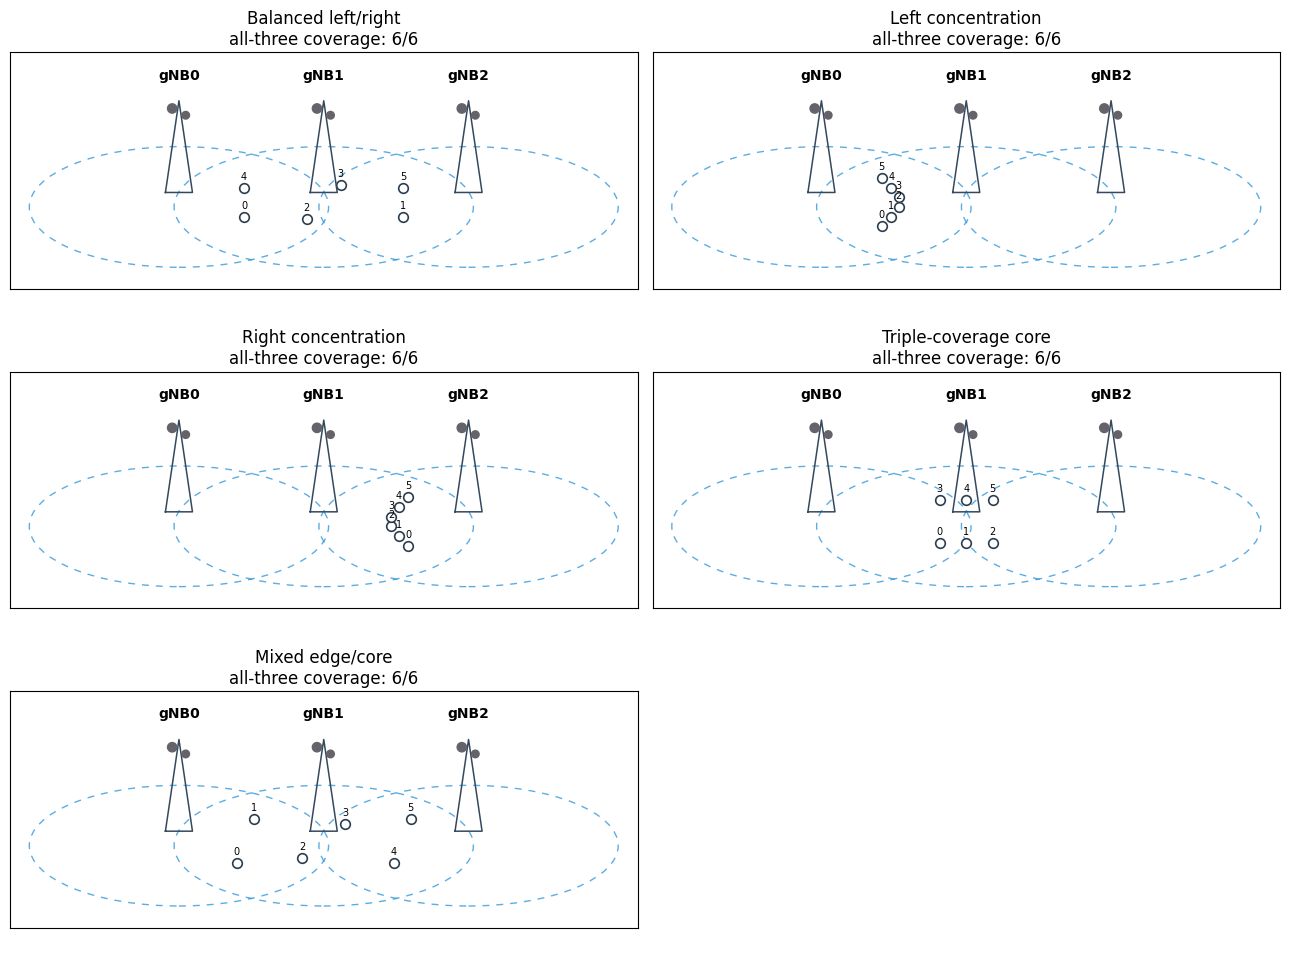

In [3]:
def draw_tower(ax, x, y=20.0):
    h, w = 190.0, 28.0
    ax.plot([x - w, x, x + w, x - w], [y, y + h, y, y], color="#34495e", linewidth=1.1)
    ax.scatter([x - 14, x + 14], [y + h - 16, y + h - 30], s=[45, 30], color="#666269", zorder=4)


fig, axes = plt.subplots(3, 2, figsize=(13, 10))
axes = axes.ravel()
for ax, item in zip(axes, snapshots):
    for cfg in CENTER_LEFT_RIGHT_GNB_CONFIGS:
        ax.add_patch(Ellipse(
            (cfg["x"], -10.0), width=620.0, height=250.0,
            fill=False, linestyle=(0, (5, 5)), color="#3498db", alpha=0.8,
        ))
        draw_tower(ax, cfg["x"])
        ax.text(cfg["x"], 255, f"gNB{cfg['id']}", ha="center", weight="bold")
    for ue_id, x, y in item["positions"]:
        ax.scatter(x, y, s=48, facecolor="white", edgecolor="#2c3e50", linewidth=1.2)
        ax.text(x, y + 18, str(ue_id), ha="center", fontsize=7)
    ax.set_title(item["label"] + f"\nall-three coverage: {item['all3_count']}/6")
    ax.set_xlim(-650, 650)
    ax.set_ylim(-180, 310)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

axes[-1].axis("off")
plt.tight_layout()
plt.show()

## Load response under the same center release action

The triple-core case intentionally shows that being covered by all three gNBs is not sufficient for handover: if the center RSRP remains much stronger, the current `-3 dB` offset creates no A3 candidates.

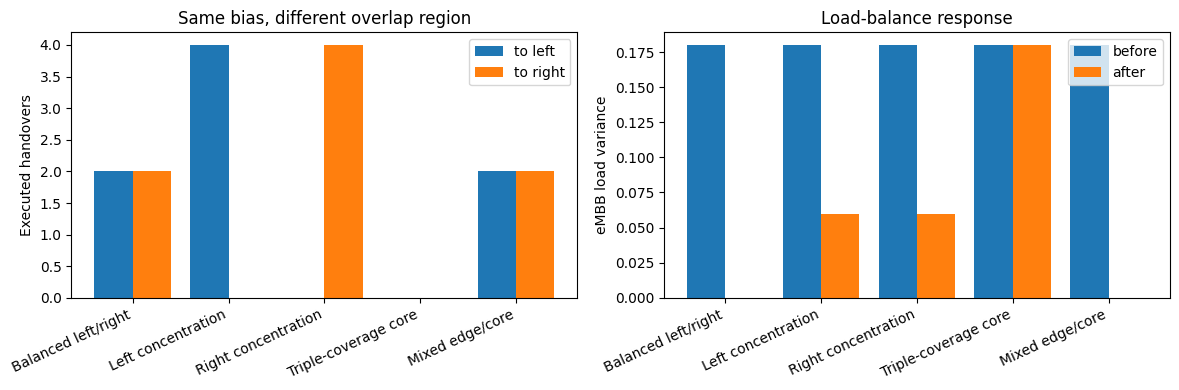

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(snapshots))
labels = [item["label"] for item in snapshots]

axes[0].bar(x - 0.2, [item["left_hos"] for item in snapshots], 0.4, label="to left")
axes[0].bar(x + 0.2, [item["right_hos"] for item in snapshots], 0.4, label="to right")
axes[0].set_xticks(x, labels, rotation=25, ha="right")
axes[0].set_ylabel("Executed handovers")
axes[0].set_title("Same bias, different overlap region")
axes[0].legend()

before_variance = [float(np.var(item["loads_before"])) for item in snapshots]
after_variance = [float(np.var(item["loads_after"])) for item in snapshots]
axes[1].bar(x - 0.2, before_variance, 0.4, label="before")
axes[1].bar(x + 0.2, after_variance, 0.4, label="after")
axes[1].set_xticks(x, labels, rotation=25, ha="right")
axes[1].set_ylabel("eMBB load variance")
axes[1].set_title("Load-balance response")
axes[1].legend()

plt.tight_layout()
plt.show()

In [5]:
by_name = {item["name"]: item for item in snapshots}
assert all(item["all3_count"] == 6 for item in snapshots)
assert by_name["fixed_center_embb_left_overlap"]["left_hos"] == 4
assert by_name["fixed_center_embb_right_overlap"]["right_hos"] == 4
assert by_name["fixed_center_embb_left_right"]["left_hos"] == 2
assert by_name["fixed_center_embb_left_right"]["right_hos"] == 2
assert by_name["fixed_center_embb_triple_core"]["handovers"] == 0

print("PASS: all scenario variants guarantee three-cell coverage and produce the expected region-dependent behavior.")

PASS: all scenario variants guarantee three-cell coverage and produce the expected region-dependent behavior.
